# Churn Analysis — CART, C4.5 & Neural Network
### Implementation
---
**Models:** CART (Gini) · C4.5 (Entropy) · MLP Neural Network  
**Topics:** Decision Trees · Confusion Matrix · Cost-Benefit · Lift & Gains · Model Comparison


## Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler, LabelEncoder
from sklearn.impute          import SimpleImputer
from sklearn.tree            import DecisionTreeClassifier, plot_tree
from sklearn.neural_network  import MLPClassifier
from sklearn.metrics         import confusion_matrix, ConfusionMatrixDisplay


## Helper Functions

In [5]:
def compute_metrics(cm):
    """Six standard classification metrics from a confusion matrix."""
    tn, fp, fn, tp = cm.ravel()
    n = tn + fp + fn + tp
    return {
        'FP_rate':     round(fp/(fp+tn), 4) if (fp+tn)>0 else 0,
        'FN_rate':     round(fn/(fn+tp), 4) if (fn+tp)>0 else 0,
        'error_rate':  round((fp+fn)/n,  4),
        'accuracy':    round((tp+tn)/n,  4),
        'sensitivity': round(tp/(tp+fn), 4) if (tp+fn)>0 else 0,
        'specificity': round(tn/(tn+fp), 4) if (tn+fp)>0 else 0,
    }

def print_metrics(label, m):
    """Pretty-print the six performance metrics."""
    print(f'\n{"="*55}\n  {label}\n{"="*55}')
    print(f'  a) FP rate     = {m["FP_rate"]}')
    print(f'  b) FN rate     = {m["FN_rate"]}')
    print(f'  c) Error rate  = {m["error_rate"]}')
    print(f'  d) Accuracy    = {m["accuracy"]}')
    print(f'  e) Sensitivity = {m["sensitivity"]}')
    print(f'  f) Specificity = {m["specificity"]}')
    print(f'{"="*55}\n')

def cost_benefit(cm, b_tp=100, b_tn=0, c_fp=-20, c_fn=-200):
    """
    Dollar-value cost/benefit from a confusion matrix.
    TP +$100 : successful retention  |  TN $0   : loyal customer, no action
    FP -$20  : wasted offer          |  FN -$200 : missed churner, lost forever
    """
    tn, fp, fn, tp = cm.ravel()
    n     = tn + fp + fn + tp
    total = tp*b_tp + tn*b_tn + fp*c_fp + fn*c_fn
    return {'TP':tp, 'FP':fp, 'TN':tn, 'FN':fn,
            'Total_Cost': total,
            'Expected_per_Case': round(total/n, 2)}

def lift_gains_table(y_true, y_proba, cutoffs=(0.1,0.2,0.33,0.4,0.5)):
    """Lift and cumulative gains at each population-percentage cutoff."""
    df = (pd.DataFrame({'true': np.asarray(y_true), 'proba': y_proba})
            .sort_values('proba', ascending=False).reset_index(drop=True))
    base = df['true'].mean()
    rows = []
    for c in cutoffs:
        n   = max(1, int(len(df)*c))
        top = df.head(n)
        rows.append({'cutoff_%': int(c*100),
                     'lift':    round(top['true'].mean()/base, 3),
                     'gains_%': round(top['true'].sum()/df['true'].sum()*100, 1)})
    return pd.DataFrame(rows)

def plot_lift(models_probas, y_test, title, cutoffs=(0.1,0.2,0.33,0.4,0.5)):
    """Lift curve(s) with random baseline."""
    n, base = len(y_test), y_test.mean()
    pct     = np.linspace(0.01, 1, 200)
    colors  = ['#5563DE','#E05A3A','#2CA58D','#F4A261']
    fig, ax = plt.subplots(figsize=(8,5))
    for i,(label,proba) in enumerate(models_probas.items()):
        ranked = (pd.DataFrame({'true':np.asarray(y_test),'proba':proba})
                    .sort_values('proba',ascending=False).reset_index(drop=True))
        lifts  = [ranked.head(max(1,int(p*n)))['true'].mean()/base for p in pct]
        ax.plot(pct*100, lifts, label=label, color=colors[i%4], linewidth=2)
        for c in cutoffs:
            lv = ranked.head(max(1,int(c*n)))['true'].mean()/base
            ax.scatter(c*100, lv, color=colors[i%4], zorder=5, s=40)
            ax.annotate(f'{lv:.2f}', (c*100,lv), xytext=(5,5),
                        textcoords='offset points', fontsize=8)
    ax.axhline(1, color='gray', linestyle='--', linewidth=1.2, label='Random baseline')
    ax.set(xlabel='% Population Contacted', ylabel='Lift', title=title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_gains(models_probas, y_test, title):
    """Cumulative gains chart with random and perfect-model baselines."""
    n, tot = len(y_test), y_test.sum()
    pct    = np.linspace(0, 1, 200)
    colors = ['#5563DE','#E05A3A','#2CA58D','#F4A261']
    fig, ax = plt.subplots(figsize=(8,5))
    for i,(label,proba) in enumerate(models_probas.items()):
        ranked = (pd.DataFrame({'true':np.asarray(y_test),'proba':proba})
                    .sort_values('proba',ascending=False).reset_index(drop=True))
        gains  = [ranked.head(max(1,int(p*n)))['true'].sum()/tot*100 for p in pct]
        ax.plot(pct*100, gains, label=label, color=colors[i%4], linewidth=2)
    ax.plot([0,100],[0,100],'gray',linestyle='--',linewidth=1.2,label='Random baseline')
    ax.plot([0,tot/n*100,100],[0,100,100],'green',linestyle=':',linewidth=1.5,label='Perfect model')
    ax.set(xlabel='% Population Contacted', ylabel='% Churners Captured',
           title=title, xlim=(0,100), ylim=(0,105))
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def show_tree(model, feature_names, title, max_depth=3):
    """Visualise a decision tree up to max_depth levels."""
    depth = min(max_depth, model.get_depth())
    fig, ax = plt.subplots(figsize=(20, depth*3 + 2))
    plot_tree(model, feature_names=feature_names,
              class_names=['Stay','Churn'],
              filled=True, rounded=True, fontsize=8,
              max_depth=max_depth, ax=ax,
              impurity=True, proportion=False)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout(); plt.show()
    print(f'  Full tree depth : {model.get_depth()}')
    print(f'  Total leaves    : {model.get_n_leaves()}')
    print(f'  Showing first {max_depth} levels for readability.')




## Data Preprocessing Pipeline

In [ ]:
print('='*60)
print('  DATA PREPROCESSING PIPELINE')
print('='*60)

# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv("ChurnDataSet.csv")         
print(f'Loaded : {df.shape[0]} rows x {df.shape[1]} columns')
print(df.head(3))

# ── Target & features ────────────────────────────────────────────────────────
X = df.drop(columns=['Churn'])
y = LabelEncoder().fit_transform(df['Churn'])  

# ── Column types ─────────────────────────────────────────────────────────────
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
print(f'Numeric: {len(num_cols)}  |  Categorical: {len(cat_cols)}')

# ── Imputation ───────────────────────────────────────────────────────────────
X[num_cols] = SimpleImputer(strategy='mean').fit_transform(X[num_cols])
if cat_cols:
    X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    print(f'Post-encoding features: {X.shape[1]}')

# ── Drop highly correlated features (|r| > 0.80) ─────────────────────────────
upper   = X.corr().abs().where(np.triu(np.ones(X.corr().shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.8)]
if to_drop:
    X.drop(columns=to_drop, inplace=True)
    print(f'Dropped correlated: {to_drop}')
else:
    print('No highly correlated features found.')

# ── Train / Test split 70/30 stratified ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}  |  Churn rate: {y_train.mean():.2%}')

# ── Scaling (MLP only) ───────────────────────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

feature_names = X_train.columns.tolist()   # saved for tree visualisation

# Storage dicts
all_metrics, all_costs, all_probas = {}, {}, {}



  DATA PREPROCESSING PIPELINE
Loaded : 667 rows x 20 columns
  State  Account length  Area code International plan Voice mail plan  \
0    LA             117        408                 No              No   
1    IN              65        415                 No              No   
2    NY             161        415                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             31.37              351.6               80             29.89   
1             21.95              228.5               83             19.42   
2             56.59              317.8               97             27.01   

   Total night minutes  Total night calls  Total night charge  \
0              

## CART Default (Gini, No Cost Adjustment)

CART Default (Gini)

  CART Default
  a) FP rate     = 0.0349
  b) FN rate     = 0.4828
  c) Error rate  = 0.0995
  d) Accuracy    = 0.9005
  e) Sensitivity = 0.5172
  f) Specificity = 0.9651



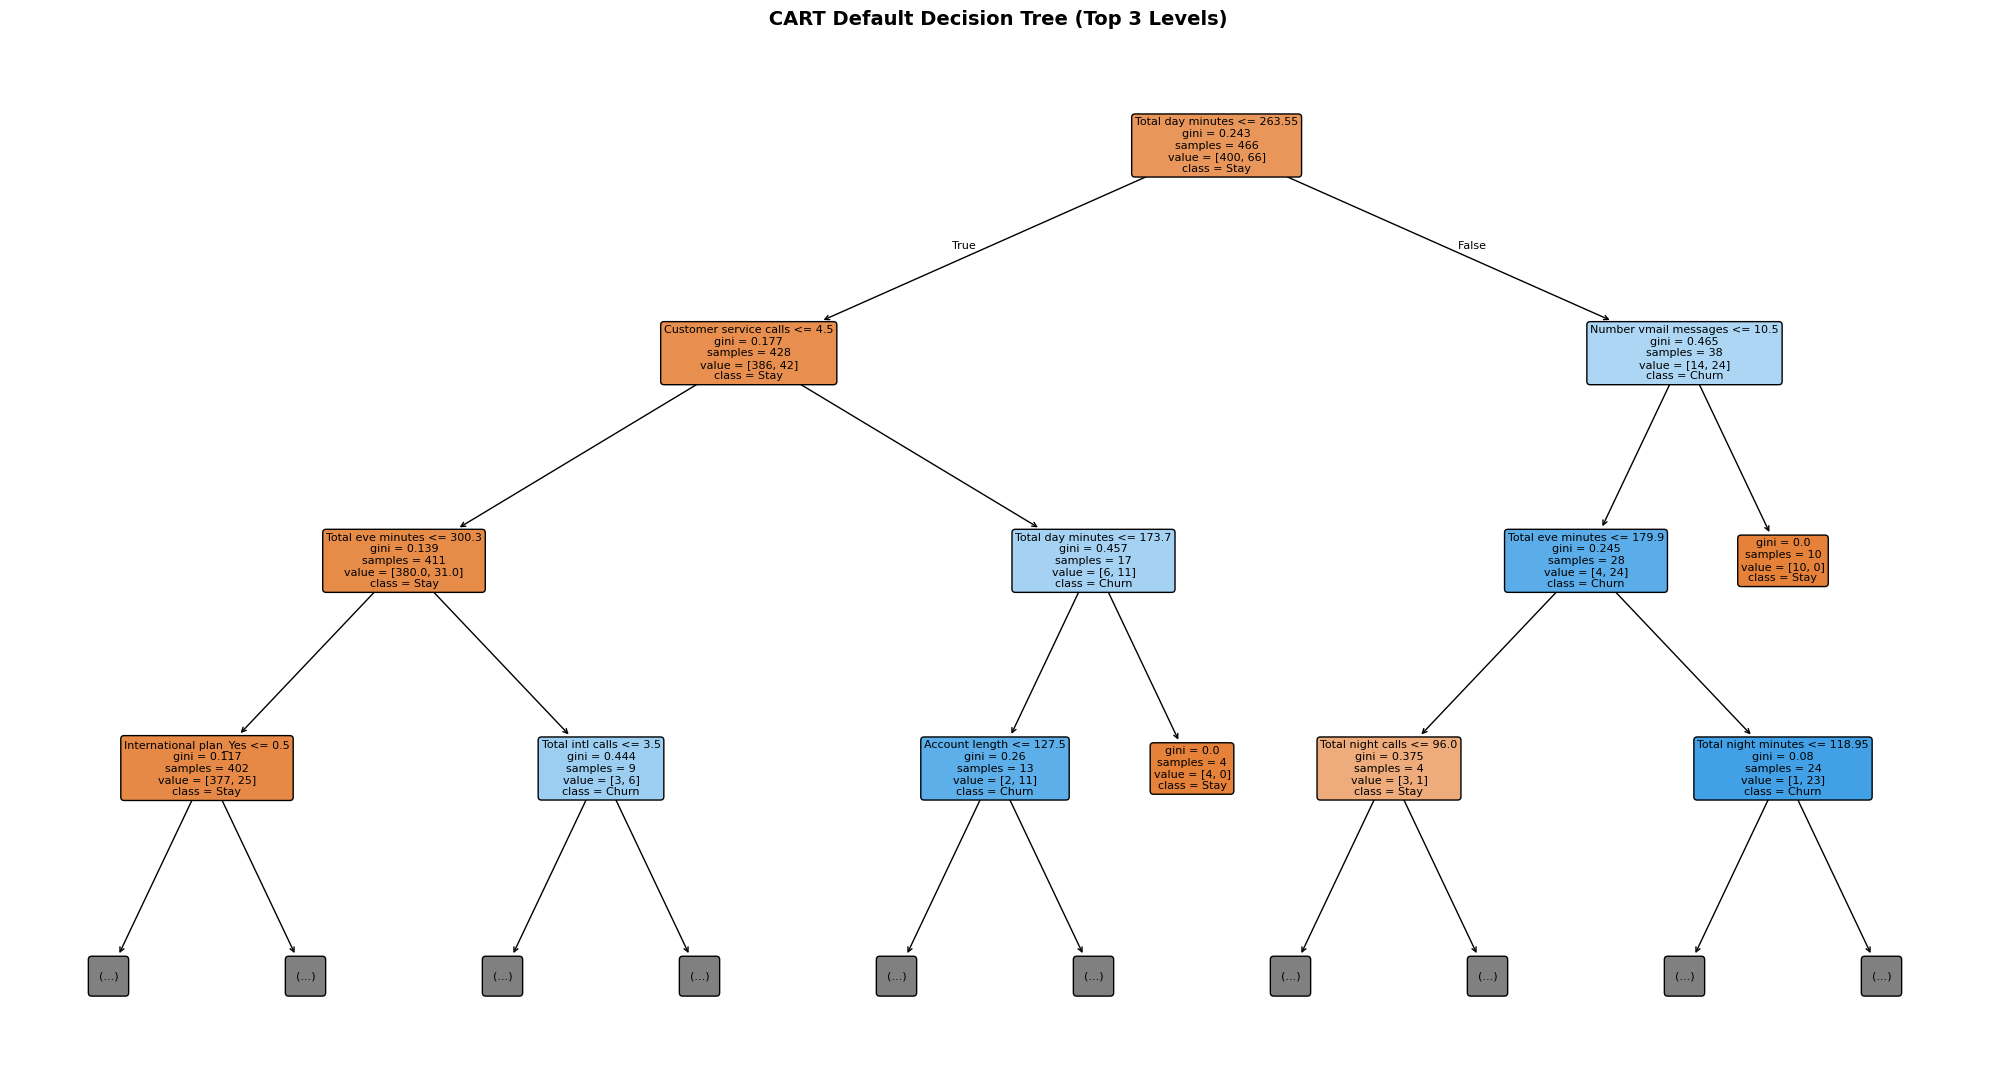

  Full tree depth : 12
  Total leaves    : 40
  Showing first 3 levels for readability.


In [21]:
print('='*60)
print('CART Default (Gini)')
print('='*60)

cart_def = DecisionTreeClassifier(criterion='gini', random_state=42)
cart_def.fit(X_train, y_train)

y_pred_cd = cart_def.predict(X_test)
y_prob_cd = cart_def.predict_proba(X_test)[:,1]
cm_cd     = confusion_matrix(y_test, y_pred_cd)
m_cd      = compute_metrics(cm_cd)
all_metrics['CART_default'] = m_cd
all_probas['CART_default']  = y_prob_cd

print_metrics('CART Default', m_cd)



# ── Decision Tree Visualisation (first 3 levels) ──────────────────────────────
show_tree(cart_def, feature_names, ' CART Default Decision Tree (Top 3 Levels)')


**Interpretation:**  
Default CART uses Gini impurity to find the best split at each node, optimising global accuracy.  
On imbalanced churn data this produces a **high FN rate** — many churners predicted as Stay — the most expensive mistake.  
The tree diagram shows which features the model splits on first: these are the most discriminative features in the dataset.


## Business Reasoning on Error Costs

In churn prediction  (Positive class = Churn): FALSE NEGATIVE (FN) — predicted Stay, actual Churn
No retention action taken; customer leaves permanently.
# Cost: lost lifetime value  ~= -$200 per missed churner.

  FALSE POSITIVE (FP) — predicted Churn, actual Stay
    Unnecessary retention offer sent to a loyal customer.
    Cost: wasted incentive budget  ~= -$20 per false alarm.

  CONCLUSION: FN is ~10x more expensive than FP.
  This asymmetry justifies COST-SENSITIVE modelling in below.



## CART Adjusted (FN Penalty × 5)

In [8]:
print('='*60)
print('   CART Adjusted  (class_weight={1:5, 0:1})')
print('='*60)

cart_adj = DecisionTreeClassifier(
    criterion='gini',
    class_weight={1:5, 0:1},   # churn class penalised 5x
    random_state=42)
cart_adj.fit(X_train, y_train)

y_pred_ca = cart_adj.predict(X_test)
y_prob_ca = cart_adj.predict_proba(X_test)[:,1]
cm_ca     = confusion_matrix(y_test, y_pred_ca)
m_ca      = compute_metrics(cm_ca)
all_metrics['CART_adjusted'] = m_ca
all_probas['CART_adjusted']  = y_prob_ca

print_metrics('CART Adjusted', m_ca)


# ── Metric Comparison Table ───────────────────────────────────────────────────
print('Metric comparison — Default vs Adjusted:')
print(pd.DataFrame({
    'Metric':        ['FP_rate','FN_rate','Sensitivity','Specificity','Error_rate','Accuracy'],
    'CART_Default':  [m_cd['FP_rate'],m_cd['FN_rate'],m_cd['sensitivity'],
                      m_cd['specificity'],m_cd['error_rate'],m_cd['accuracy']],
    'CART_Adjusted': [m_ca['FP_rate'],m_ca['FN_rate'],m_ca['sensitivity'],
                      m_ca['specificity'],m_ca['error_rate'],m_ca['accuracy']],
}).to_string(index=False))


   CART Adjusted  (class_weight={1:5, 0:1})

  CART Adjusted
  a) FP rate     = 0.0465
  b) FN rate     = 0.4138
  c) Error rate  = 0.0995
  d) Accuracy    = 0.9005
  e) Sensitivity = 0.5862
  f) Specificity = 0.9535

Metric comparison — Default vs Adjusted:
     Metric  CART_Default  CART_Adjusted
    FP_rate        0.0349         0.0465
    FN_rate        0.4828         0.4138
Sensitivity        0.5172         0.5862
Specificity        0.9651         0.9535
 Error_rate        0.0995         0.0995
   Accuracy        0.9005         0.9005


**Interpretation:**  
Penalising FN × 5 forces the tree to predict churn more aggressively — notice how the tree structure changes.  
- **Sensitivity ↑** — fewer missed churners (lower FN rate)  
- **Specificity ↓** — more false alarms (higher FP rate)  

This trade-off is worthwhile when a missed churner (−$200) far outweighs a wasted offer (−$20).


## Cost/Benefit Analysis: CART Default

In [9]:
print('='*60)
print(' Cost/Benefit: CART Default')
print('='*60)

cb_cd = cost_benefit(cm_cd)
all_costs['CART_default'] = cb_cd

print(f'  TP  (caught churner,  +$100) : {cb_cd["TP"]}')
print(f'  TN  (loyal, no action,  $0)  : {cb_cd["TN"]}')
print(f'  FP  (false alarm,     -$20)  : {cb_cd["FP"]}')
print(f'  FN  (missed churner, -$200)  : {cb_cd["FN"]}')
print(f'  {chr(9472)*42}')
print(f'  Total Cost / Benefit         : ${cb_cd["Total_Cost"]:,}')
print(f'  Expected Value per Case      : ${cb_cd["Expected_per_Case"]}')


 Cost/Benefit: CART Default
  TP  (caught churner,  +$100) : 15
  TN  (loyal, no action,  $0)  : 166
  FP  (false alarm,     -$20)  : 6
  FN  (missed churner, -$200)  : 14
  ──────────────────────────────────────────
  Total Cost / Benefit         : $-1,420
  Expected Value per Case      : $-7.06


## Cost/Benefit: CART Default vs Adjusted

In [10]:
print('='*60)
print('  Cost/Benefit Comparison')
print('='*60)

cb_ca = cost_benefit(cm_ca)
all_costs['CART_adjusted'] = cb_ca

print(pd.DataFrame({
    'Metric':        ['TP','FP','TN','FN','Total_Cost($)','Exp/Case($)'],
    'CART_Default':  [cb_cd['TP'],cb_cd['FP'],cb_cd['TN'],cb_cd['FN'],
                      cb_cd['Total_Cost'],cb_cd['Expected_per_Case']],
    'CART_Adjusted': [cb_ca['TP'],cb_ca['FP'],cb_ca['TN'],cb_ca['FN'],
                      cb_ca['Total_Cost'],cb_ca['Expected_per_Case']],
}).to_string(index=False))

winner = 'CART_Adjusted' if cb_ca['Expected_per_Case'] > cb_cd['Expected_per_Case'] else 'CART_Default'
print(f'\n  Better expected value per case: {winner}')


  Cost/Benefit Comparison
       Metric  CART_Default  CART_Adjusted
           TP         15.00          17.00
           FP          6.00           8.00
           TN        166.00         164.00
           FN         14.00          12.00
Total_Cost($)      -1420.00        -860.00
  Exp/Case($)         -7.06          -4.28

  Better expected value per case: CART_Adjusted


**Interpretation:**  
More FP (−$20 each) is acceptable if it eliminates costly FN (−$200 each).  
**Expected Value per Case** is the single best decision criterion when costs are asymmetric.


In [11]:
print(df.columns)

df.info()

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    str    
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    str    
 4   Voice mail plan         667 non-null    str    
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes 

## Lift Chart: CART Default

  Lift Chart: CART Default
CART Default Lift & Gains:
 cutoff_%  lift  gains_%
       10 4.852     48.3
       20 2.599     51.7
       33 1.785     58.6
       40 1.559     62.1
       50 1.248     62.1


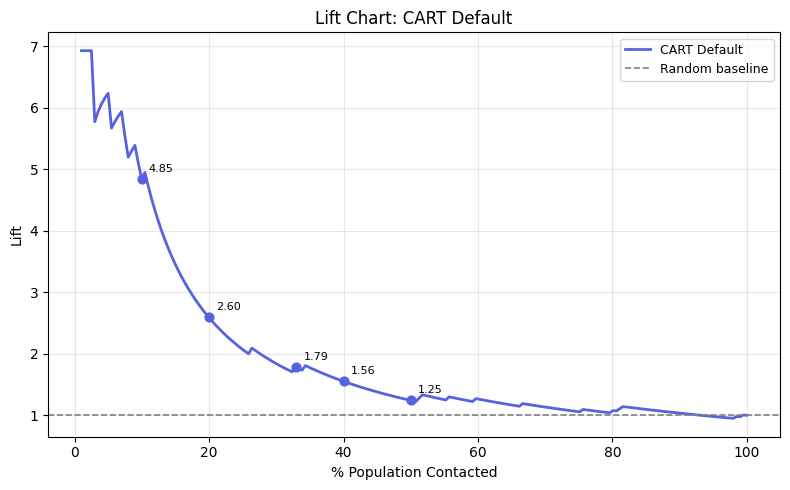

In [12]:
print('='*60)
print('  Lift Chart: CART Default')
print('='*60)
lt_cd = lift_gains_table(y_test, y_prob_cd)
print('CART Default Lift & Gains:')
print(lt_cd.to_string(index=False))

plot_lift({'CART Default': y_prob_cd}, y_test,
          'Lift Chart: CART Default')


## Gains Chart: CART Default

   Gains Chart: CART Default


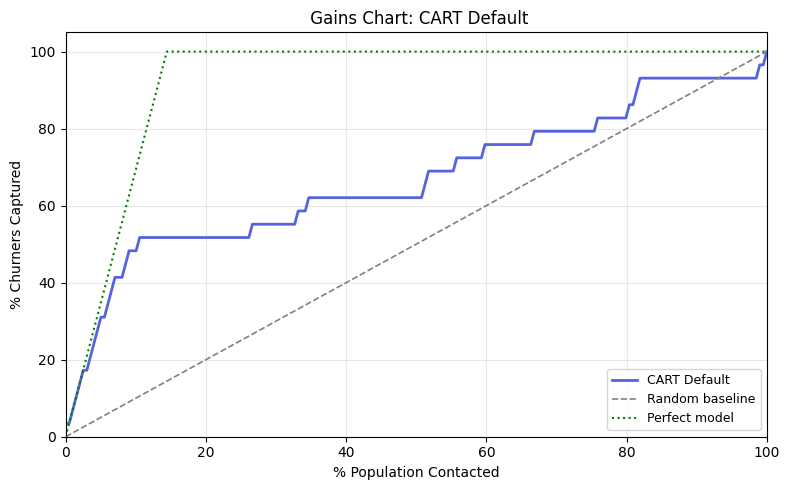


Lift vs Gains — the mathematical relationship:

  Gains @ p = % of actual churners captured in top p% of population
  Lift  @ p = Gains @ p / p   (how much BETTER than random)

  Example: Gains=60% at top-20% -> Lift = 60/20 = 3.0x

  Both charts rank customers by descending predicted probability.
  A steep early Gains curve always produces a high early Lift.



In [13]:
print('='*60)
print('   Gains Chart: CART Default')
print('='*60)

plot_gains({'CART Default': y_prob_cd}, y_test,
           ' Gains Chart: CART Default')

print("""
Lift vs Gains — the mathematical relationship:

  Gains @ p = % of actual churners captured in top p% of population
  Lift  @ p = Gains @ p / p   (how much BETTER than random)

  Example: Gains=60% at top-20% -> Lift = 60/20 = 3.0x

  Both charts rank customers by descending predicted probability.
  A steep early Gains curve always produces a high early Lift.
""")


##  Lift Chart: CART Adjusted

Lift Chart: CART Adjusted
CART Adjusted Lift & Gains:
 cutoff_%  lift  gains_%
       10 4.852     48.3
       20 2.946     58.6
       33 1.995     65.5
       40 1.646     65.5
       50 1.386     69.0


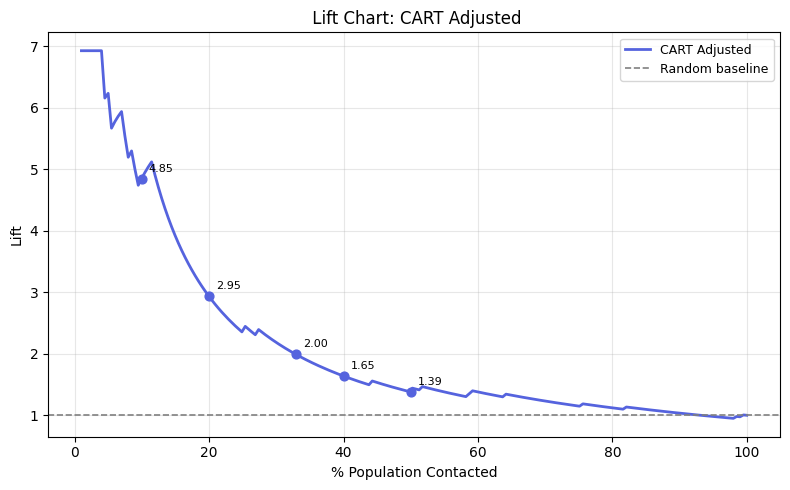

In [14]:
print('='*60)
print('Lift Chart: CART Adjusted')
print('='*60)

lt_ca = lift_gains_table(y_test, y_prob_ca)
print('CART Adjusted Lift & Gains:')
print(lt_ca.to_string(index=False))

plot_lift({'CART Adjusted': y_prob_ca}, y_test,
          ' Lift Chart: CART Adjusted')


## Combined Lift Chart: CART Default vs Adjusted

Combined CART Lift Chart


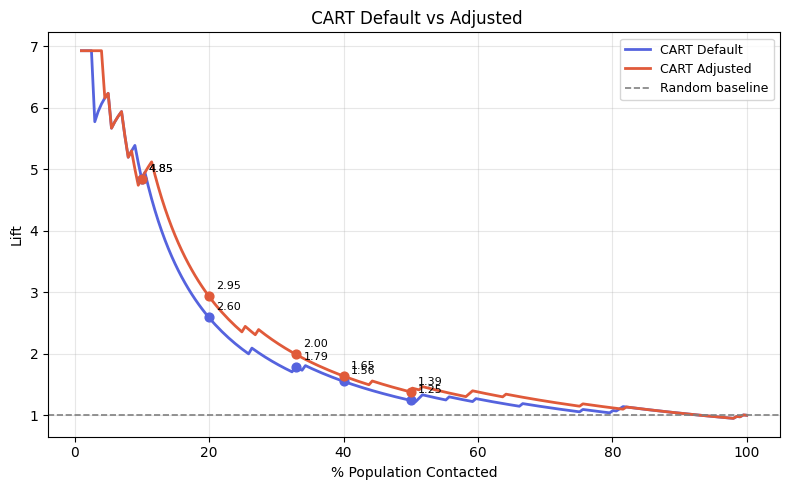

Side-by-side lift/gains:
 cutoff_%  Lift_Default  Gains_Default%  Lift_Adjusted  Gains_Adjusted%
       10         4.852            48.3          4.852             48.3
       20         2.599            51.7          2.946             58.6
       33         1.785            58.6          1.995             65.5
       40         1.559            62.1          1.646             65.5
       50         1.248            62.1          1.386             69.0


In [15]:
print('='*60)
print('Combined CART Lift Chart')
print('='*60)

plot_lift({'CART Default': y_prob_cd, 'CART Adjusted': y_prob_ca},
          y_test, ' CART Default vs Adjusted')

side = lt_cd.rename(columns={'lift':'Lift_Default','gains_%':'Gains_Default%'}).copy()
side['Lift_Adjusted']   = lt_ca['lift'].values
side['Gains_Adjusted%'] = lt_ca['gains_%'].values
print('Side-by-side lift/gains:')
print(side.to_string(index=False))


**Interpretation:**  
- **Top 10–20%:** The model with steeper early lift ranks the highest-risk churners more accurately — the most valuable targeting zone.  
- **Mid-range 20–50%:** Adjusted model often stays competitive as probability scores shift toward churn.  
- **Beyond 50%:** Both models converge — the population is mostly non-churners.


##  C4.5 Model (Entropy / Information Gain Ratio)

 C4.5 Default & Adjusted (Entropy)

  C4.5 Default
  a) FP rate     = 0.0233
  b) FN rate     = 0.3448
  c) Error rate  = 0.0697
  d) Accuracy    = 0.9303
  e) Sensitivity = 0.6552
  f) Specificity = 0.9767


  C4.5 Adjusted
  a) FP rate     = 0.0523
  b) FN rate     = 0.3103
  c) Error rate  = 0.0896
  d) Accuracy    = 0.9104
  e) Sensitivity = 0.6897
  f) Specificity = 0.9477



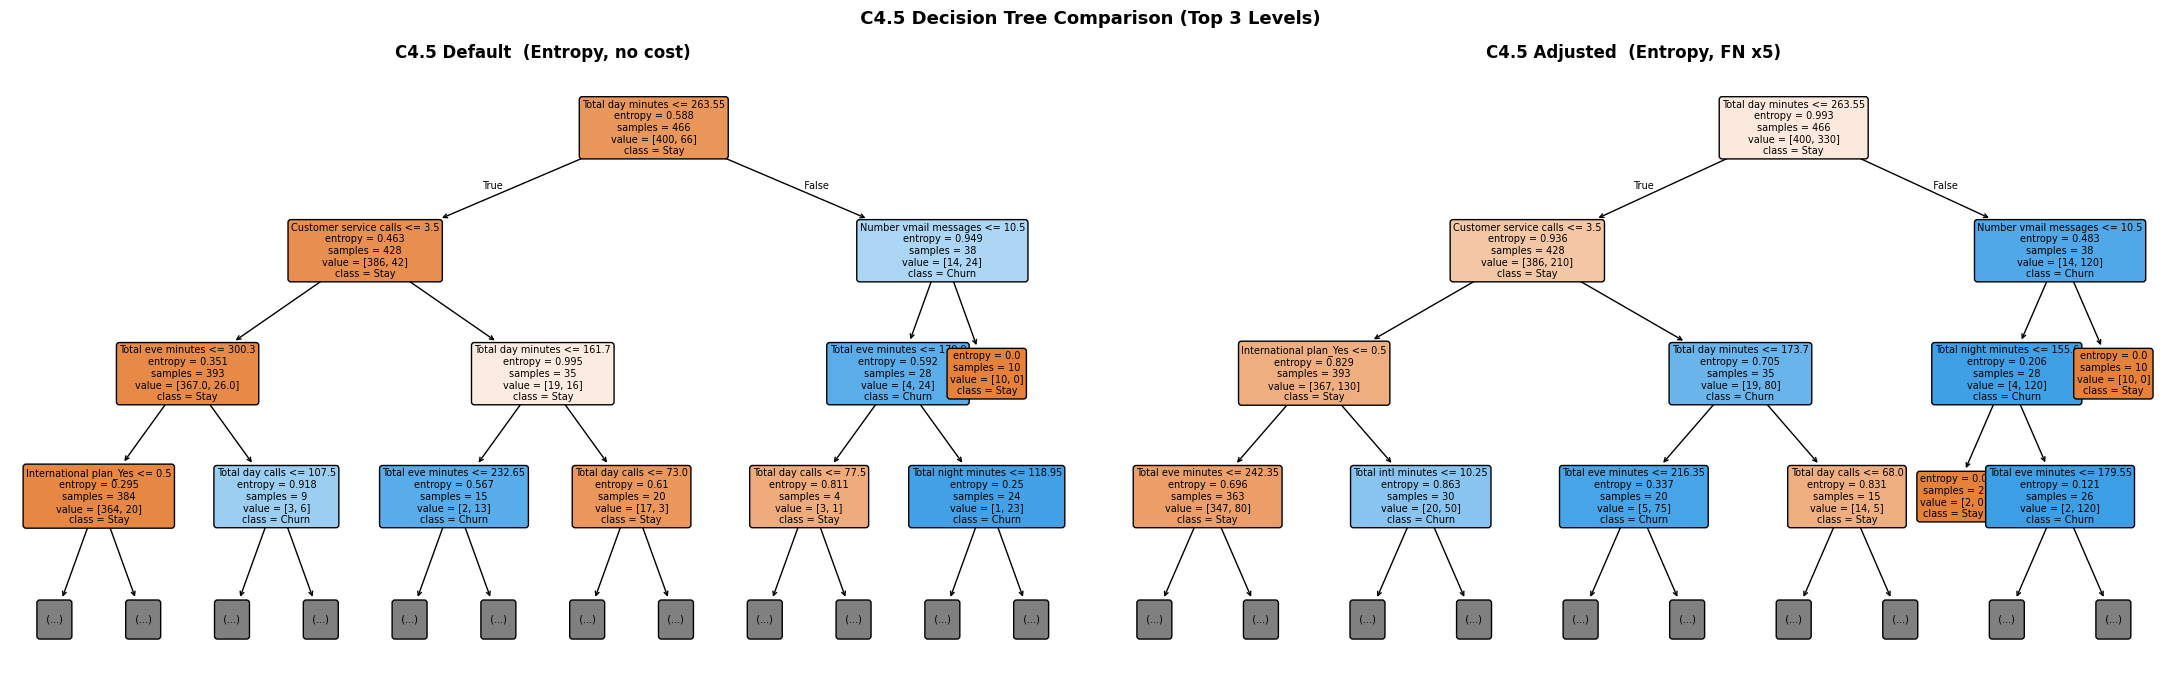

C4.5 Cost/Benefit Summary:
       Metric  C45_Default  C45_Adjusted
           TP         19.0          20.0
           FP          4.0           9.0
           TN        168.0         163.0
           FN         10.0           9.0
Total_Cost($)       -180.0          20.0
  Exp/Case($)         -0.9           0.1


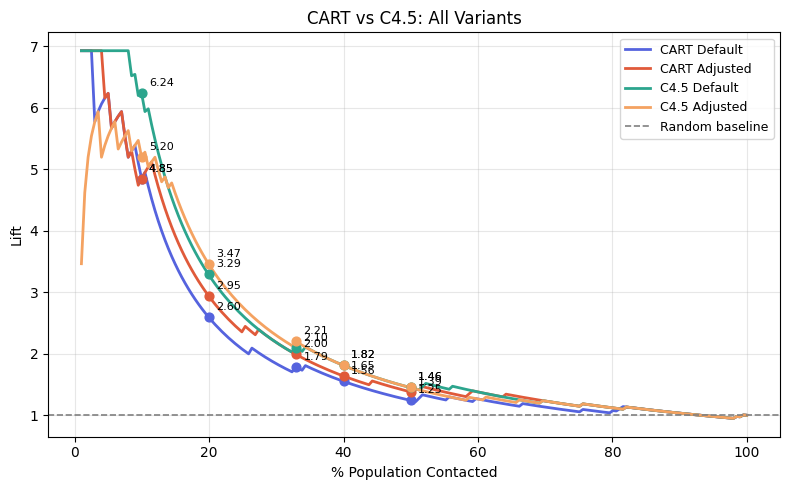

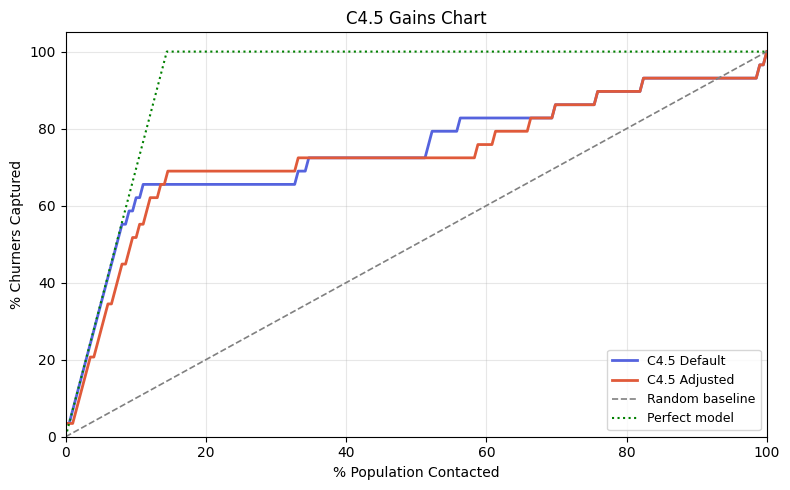


Full CART vs C4.5 metric comparison:
     Metric  CART_Default  CART_Adjusted  C45_Default  C45_Adjusted
    FP_rate        0.0349         0.0465       0.0233        0.0523
    FN_rate        0.4828         0.4138       0.3448        0.3103
 error_rate        0.0995         0.0995       0.0697        0.0896
   accuracy        0.9005         0.9005       0.9303        0.9104
sensitivity        0.5172         0.5862       0.6552        0.6897
specificity        0.9651         0.9535       0.9767        0.9477


In [22]:
print('='*60)
print(' C4.5 Default & Adjusted (Entropy)')
print('='*60)

# C4.5 uses entropy / information gain ratio — sklearn exposes this as criterion='entropy'
c45_def = DecisionTreeClassifier(criterion='entropy', random_state=42)
c45_adj = DecisionTreeClassifier(criterion='entropy',
                                  class_weight={1:5, 0:1}, random_state=42)
c45_def.fit(X_train, y_train)
c45_adj.fit(X_train, y_train)

y_prob_c45d = c45_def.predict_proba(X_test)[:,1]
y_prob_c45a = c45_adj.predict_proba(X_test)[:,1]
cm_c45d     = confusion_matrix(y_test, c45_def.predict(X_test))
cm_c45a     = confusion_matrix(y_test, c45_adj.predict(X_test))
m_c45d      = compute_metrics(cm_c45d)
m_c45a      = compute_metrics(cm_c45a)
all_metrics['C45_default']  = m_c45d
all_metrics['C45_adjusted'] = m_c45a
all_probas['C45_default']   = y_prob_c45d
all_probas['C45_adjusted']  = y_prob_c45a

print_metrics('C4.5 Default',  m_c45d)
print_metrics('C4.5 Adjusted', m_c45a)

# ── C4.5 Decision Trees ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 7))
plot_tree(c45_def, feature_names=feature_names, class_names=['Stay','Churn'],
          filled=True, rounded=True, fontsize=7, max_depth=3, ax=axes[0])
axes[0].set_title('C4.5 Default  (Entropy, no cost)', fontweight='bold', fontsize=12)
plot_tree(c45_adj, feature_names=feature_names, class_names=['Stay','Churn'],
          filled=True, rounded=True, fontsize=7, max_depth=3, ax=axes[1])
axes[1].set_title('C4.5 Adjusted  (Entropy, FN x5)', fontweight='bold', fontsize=12)
plt.suptitle(' C4.5 Decision Tree Comparison (Top 3 Levels)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Cost / Benefit ────────────────────────────────────────────────────────────
cb_c45d = cost_benefit(cm_c45d)
cb_c45a = cost_benefit(cm_c45a)
all_costs['C45_default']  = cb_c45d
all_costs['C45_adjusted'] = cb_c45a

print('C4.5 Cost/Benefit Summary:')
print(pd.DataFrame({
    'Metric':       ['TP','FP','TN','FN','Total_Cost($)','Exp/Case($)'],
    'C45_Default':  [cb_c45d['TP'],cb_c45d['FP'],cb_c45d['TN'],cb_c45d['FN'],
                     cb_c45d['Total_Cost'],cb_c45d['Expected_per_Case']],
    'C45_Adjusted': [cb_c45a['TP'],cb_c45a['FP'],cb_c45a['TN'],cb_c45a['FN'],
                     cb_c45a['Total_Cost'],cb_c45a['Expected_per_Case']],
}).to_string(index=False))

# ── Lift tables ───────────────────────────────────────────────────────────────
lt_c45d = lift_gains_table(y_test, y_prob_c45d)
lt_c45a = lift_gains_table(y_test, y_prob_c45a)

# ── All-variant lift chart ────────────────────────────────────────────────────
plot_lift(
    {'CART Default':y_prob_cd,'CART Adjusted':y_prob_ca,
     'C4.5 Default':y_prob_c45d,'C4.5 Adjusted':y_prob_c45a},
    y_test, 'CART vs C4.5: All Variants')

plot_gains({'C4.5 Default':y_prob_c45d,'C4.5 Adjusted':y_prob_c45a},
           y_test, 'C4.5 Gains Chart')

# ── Full 4-model metric table ─────────────────────────────────────────────────
print('\nFull CART vs C4.5 metric comparison:')
print(pd.DataFrame({
    'Metric':        list(m_cd.keys()),
    'CART_Default':  list(m_cd.values()),
    'CART_Adjusted': list(m_ca.values()),
    'C45_Default':   list(m_c45d.values()),
    'C45_Adjusted':  list(m_c45a.values()),
}).to_string(index=False))


**CART (Gini) vs C4.5 (Entropy):**  
- **Gini** measures class impurity — computationally cheaper, slight preference for balanced splits.  
- **Entropy** measures information content; C4.5 uses gain ratio, reducing bias toward high-cardinality features.  
- Compare the tree diagrams: the root feature and split thresholds often differ between criteria.  
- In practice on tabular data, performance differences are small. The **cost-adjusted variant** of either algorithm typically delivers better business value.


##  Neural Network (MLPClassifier)

   MLPClassifier  (100->50 neurons, ReLU, Adam)

  MLP Neural Network
  a) FP rate     = 0.0407
  b) FN rate     = 0.8276
  c) Error rate  = 0.1542
  d) Accuracy    = 0.8458
  e) Sensitivity = 0.1724
  f) Specificity = 0.9593

  Total Cost / Benefit  : $-4,440
  Expected Value/Case   : $-22.09


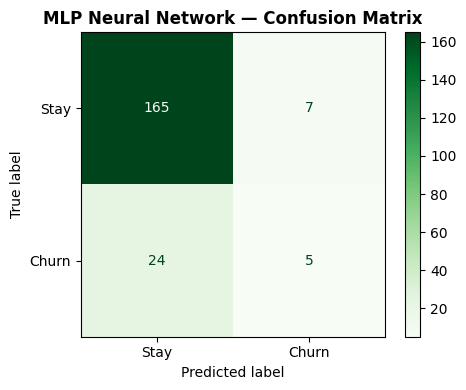

In [17]:
print('='*60)
print('   MLPClassifier  (100->50 neurons, ReLU, Adam)')
print('='*60)

mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),   # two hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42)
mlp.fit(X_train_sc, y_train)        

y_pred_mlp = mlp.predict(X_test_sc)
y_prob_mlp = mlp.predict_proba(X_test_sc)[:,1]
cm_mlp     = confusion_matrix(y_test, y_pred_mlp)
m_mlp      = compute_metrics(cm_mlp)
all_metrics['MLP'] = m_mlp
all_probas['MLP']  = y_prob_mlp

print_metrics('MLP Neural Network', m_mlp)

cb_mlp = cost_benefit(cm_mlp)
all_costs['MLP'] = cb_mlp
print(f'  Total Cost / Benefit  : ${cb_mlp["Total_Cost"]:,}')
print(f'  Expected Value/Case   : ${cb_mlp["Expected_per_Case"]}')

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(cm_mlp, display_labels=['Stay','Churn']).plot(ax=ax, cmap='Greens')
ax.set_title('MLP Neural Network — Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()


**`StandardScaler` is mandatory for MLP in this case:**  
Neural networks update weights via gradient descent. Features on different scales produce vastly different gradient magnitudes — large-valued features dominate and training diverges or stalls.  
Scaling forces all features into the same range, making gradient descent stable and fast.

**Architecture — 100 → 50 neurons:**  
- **Layer 1 (100):** learns broad feature combinations from the input  
- **Layer 2 (50):** compresses into higher-level representations  
- **ReLU:** avoids vanishing gradients · **Adam:** adapts learning rate per parameter


## Lift Chart: MLP vs CART Variants

 Lift: MLP vs CART
MLP Lift & Gains:
 cutoff_%  lift  gains_%
       10 2.772     27.6
       20 2.426     48.3
       33 1.785     58.6
       40 1.646     65.5
       50 1.386     69.0

Lift comparison at key cutoffs:
 cutoff_%  CART_Default  CART_Adjusted   MLP
       10         4.852          4.852 2.772
       20         2.599          2.946 2.426
       33         1.785          1.995 1.785
       40         1.559          1.646 1.646
       50         1.248          1.386 1.386


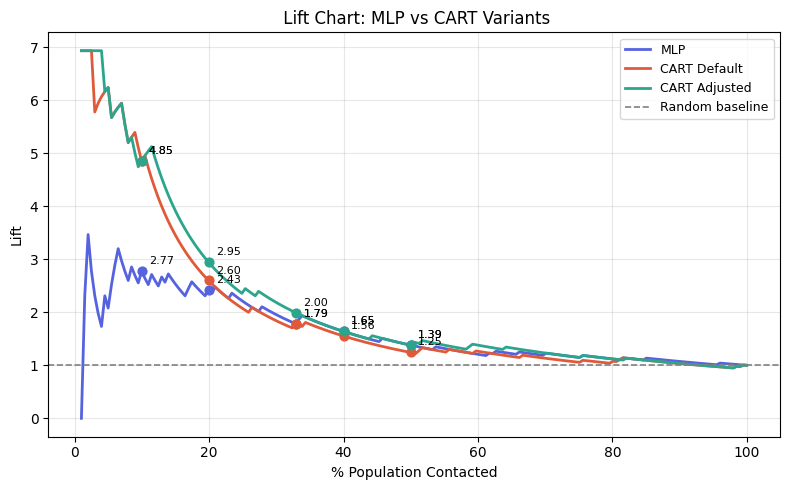

In [18]:
print('='*60)
print(' Lift: MLP vs CART')
print('='*60)

lt_mlp = lift_gains_table(y_test, y_prob_mlp)
print('MLP Lift & Gains:')
print(lt_mlp.to_string(index=False))

print('\nLift comparison at key cutoffs:')
print(pd.DataFrame({
    'cutoff_%':      [10,20,33,40,50],
    'CART_Default':  lt_cd['lift'].values,
    'CART_Adjusted': lt_ca['lift'].values,
    'MLP':           lt_mlp['lift'].values,
}).to_string(index=False))

plot_lift({'MLP':y_prob_mlp,'CART Default':y_prob_cd,'CART Adjusted':y_prob_ca},
          y_test, ' Lift Chart: MLP vs CART Variants')


**Interpretation:**  
Neural networks assign **fine-grained probability scores** giving them an advantage over axis-aligned trees at the very top of the ranked list (top 10–20%).  
At broader cutoffs (40–50%), simpler models catch up, so the easy churners are identified by all models.


## Master Comparison Lift Chart

 Master Lift Chart  (Best of each family)
Best CART : CART_adjusted
Best C4.5 : C45_adjusted


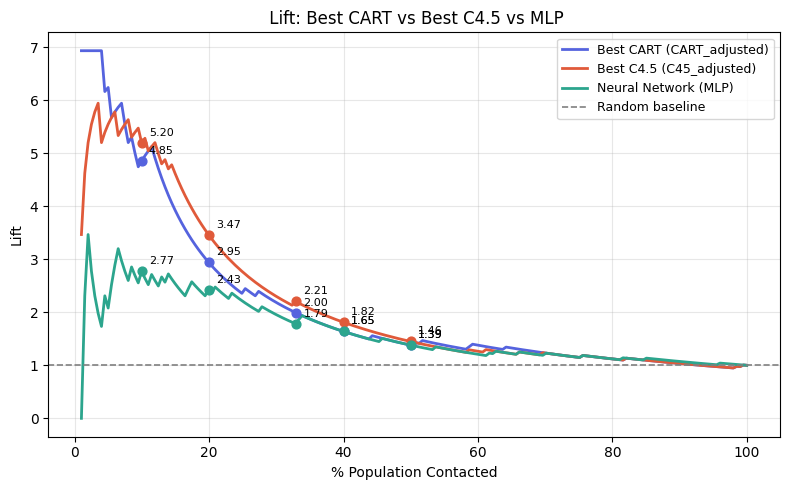


Master lift table:
 cutoff_%  CART_best  C45_best   MLP
       10      4.852     5.198 2.772
       20      2.946     3.466 2.426
       33      1.995     2.205 1.785
       40      1.646     1.819 1.646
       50      1.386     1.456 1.386

Regional lift guidance:
  Top 10-20%  -> MLP often leads; best for focused high-value campaigns.
  Top 20-50%  -> Trees competitive; more interpretable for mid-tier targeting.
  Top 50%+    -> All models converge as the population is mostly non-churners.



In [19]:
print('='*60)
print(' Master Lift Chart  (Best of each family)')
print('='*60)

best_cart_key = ('CART_adjusted'
                 if cb_ca['Expected_per_Case'] >= cb_cd['Expected_per_Case']
                 else 'CART_default')
best_c45_key  = ('C45_adjusted'
                 if cb_c45a['Expected_per_Case'] >= cb_c45d['Expected_per_Case']
                 else 'C45_default')

print(f'Best CART : {best_cart_key}')
print(f'Best C4.5 : {best_c45_key}')

plot_lift(
    {f'Best CART ({best_cart_key})': all_probas[best_cart_key],
     f'Best C4.5 ({best_c45_key})': all_probas[best_c45_key],
     'Neural Network (MLP)':        y_prob_mlp},
    y_test, ' Lift: Best CART vs Best C4.5 vs MLP')

lt_best_cart = lift_gains_table(y_test, all_probas[best_cart_key])
lt_best_c45  = lift_gains_table(y_test, all_probas[best_c45_key])
print('\nMaster lift table:')
print(pd.DataFrame({
    'cutoff_%':  lt_best_cart['cutoff_%'],
    'CART_best': lt_best_cart['lift'],
    'C45_best':  lt_best_c45['lift'],
    'MLP':       lt_mlp['lift'].values,
}).to_string(index=False))

print("""
Regional lift guidance:
  Top 10-20%  -> MLP often leads; best for focused high-value campaigns.
  Top 20-50%  -> Trees competitive; more interpretable for mid-tier targeting.
  Top 50%+    -> All models converge as the population is mostly non-churners.
""")


##  Final Discussion & Master Summary

 Final Model Comparison & Recommendation

1. ACCURACY COMPARISON
        Model  Accuracy_%
  C45_default       93.03
 C45_adjusted       91.04
 CART_default       90.05
CART_adjusted       90.05
          MLP       84.58

2. EXPECTED VALUE PER CASE ($)
        Model  Exp_$/Case
 C45_adjusted        0.10
  C45_default       -0.90
CART_adjusted       -4.28
 CART_default       -7.06
          MLP      -22.09

3. LIFT AT KEY PERCENTILES
               Lift@20%  Lift@33%  Lift@50%
Model                                      
CART_default      2.599     1.785     1.248
CART_adjusted     2.946     1.995     1.386
C45_default       3.292     2.100     1.456
C45_adjusted      3.466     2.205     1.456
MLP               2.426     1.785     1.386

4. SENSITIVITY vs SPECIFICITY
        Model  Sensitivity  Specificity
 CART_default       0.5172       0.9651
CART_adjusted       0.5862       0.9535
  C45_default       0.6552       0.9767
 C45_adjusted       0.6897       0.9477
          MLP       0.17

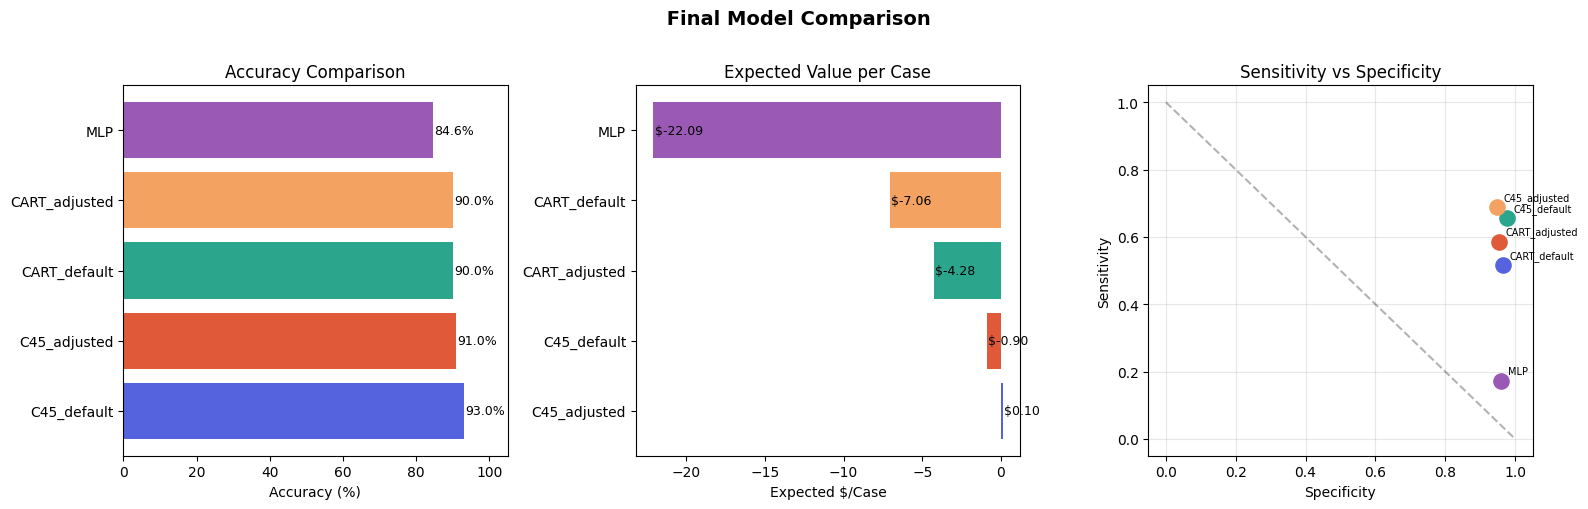

In [20]:
print('='*60)
print(' Final Model Comparison & Recommendation')
print('='*60)

# 1. Accuracy
print('\n1. ACCURACY COMPARISON')
acc_df = (pd.DataFrame([(k, round(v['accuracy']*100,2))
                         for k,v in all_metrics.items()],
                        columns=['Model','Accuracy_%'])
            .sort_values('Accuracy_%', ascending=False))
print(acc_df.to_string(index=False))

# 2. Expected value per case
print('\n2. EXPECTED VALUE PER CASE ($)')
cost_df = (pd.DataFrame([(k, v['Expected_per_Case'])
                          for k,v in all_costs.items()],
                         columns=['Model','Exp_$/Case'])
             .sort_values('Exp_$/Case', ascending=False))
print(cost_df.to_string(index=False))

# 3. Lift at key percentiles
print('\n3. LIFT AT KEY PERCENTILES')
lift_final = pd.DataFrame(
    {k: lift_gains_table(y_test, p, [0.2,0.33,0.5])['lift'].values
     for k,p in all_probas.items()},
    index=['Lift@20%','Lift@33%','Lift@50%']).T
lift_final.index.name = 'Model'
print(lift_final.round(3).to_string())

# 4. Sensitivity vs Specificity
print('\n4. SENSITIVITY vs SPECIFICITY')
print(pd.DataFrame({
    'Model':       list(all_metrics.keys()),
    'Sensitivity': [v['sensitivity'] for v in all_metrics.values()],
    'Specificity': [v['specificity'] for v in all_metrics.values()],
}).to_string(index=False))

# ── Summary bar charts ────────────────────────────────────────────────────────
colors = ['#5563DE','#E05A3A','#2CA58D','#F4A261','#9B59B6']
fig, axes = plt.subplots(1, 3, figsize=(16,5))

axes[0].barh(acc_df['Model'], acc_df['Accuracy_%'], color=colors[:len(acc_df)])
axes[0].set(xlabel='Accuracy (%)', title='Accuracy Comparison', xlim=(0,105))
for i,v in enumerate(acc_df['Accuracy_%']):
    axes[0].text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=9)

axes[1].barh(cost_df['Model'], cost_df['Exp_$/Case'], color=colors[:len(cost_df)])
axes[1].set(xlabel='Expected $/Case', title='Expected Value per Case')
for i,v in enumerate(cost_df['Exp_$/Case']):
    axes[1].text(v+0.1, i, f'${v:.2f}', va='center', fontsize=9)

for idx,(model,m) in enumerate(all_metrics.items()):
    axes[2].scatter(m['specificity'], m['sensitivity'],
                    color=colors[idx%5], s=120, zorder=5)
    axes[2].annotate(model, (m['specificity'],m['sensitivity']),
                     xytext=(5,5), textcoords='offset points', fontsize=7)
axes[2].plot([0,1],[1,0],'k--',alpha=0.3)
axes[2].set(xlabel='Specificity', ylabel='Sensitivity',
            title='Sensitivity vs Specificity')
axes[2].grid(alpha=0.3)

plt.suptitle(' Final Model Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
